In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle

In [ ]:
!kaggle datasets download -d aashidutt3/waste-segregation-image-dataset

100% 1.17G/1.17G [00:35<00:00, 35.8MB/s]
100% 1.17G/1.17G [00:35<00:00, 35.6MB/s]


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/waste-segregation-image-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [ ]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Robotics_Dataset/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Robotics_Dataset/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

Found 10736 files belonging to 2 classes.
Found 298 files belonging to 2 classes.


In [ ]:
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the CNN model
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

# Extract features from the trained CNN model
train_features = model.predict(train_ds)
train_labels = np.concatenate([y for x, y in train_ds], axis=0)
validation_features = model.predict(validation_ds)
validation_labels = np.concatenate([y for x, y in validation_ds], axis=0)

# Reshape or flatten the extracted features
train_features = np.reshape(train_features, (train_features.shape[0], -1))
validation_features = np.reshape(validation_features, (validation_features.shape[0], -1))

# Create and train the SVM classifier
svm = SVC(kernel='linear')
svm.fit(train_features, train_labels)

# Evaluate the SVM classifier
train_accuracy = svm.score(train_features, train_labels)
validation_accuracy = svm.score(validation_features, validation_labels)

print("Train accuracy:", train_accuracy)
print("Validation accuracy:", validation_accuracy)

Epoch 1/10
336/336 [==============================] - 50s 135ms/step - loss: 0.0772 - accuracy: 0.9776 - val_loss: 1.0200 - val_accuracy: 0.8826
Epoch 2/10
336/336 [==============================] - 49s 143ms/step - loss: 0.0830 - accuracy: 0.9768 - val_loss: 0.9081 - val_accuracy: 0.9128
Epoch 3/10
336/336 [==============================] - 45s 131ms/step - loss: 0.0467 - accuracy: 0.9803 - val_loss: 2.1687 - val_accuracy: 0.8188
Epoch 4/10
336/336 [==============================] - 46s 134ms/step - loss: 0.0439 - accuracy: 0.9852 - val_loss: 0.5202 - val_accuracy: 0.9128
Epoch 5/10
336/336 [==============================] - 44s 129ms/step - loss: 0.0810 - accuracy: 0.9728 - val_loss: 1.9052 - val_accuracy: 0.8960
Epoch 6/10
336/336 [==============================] - 45s 132ms/step - loss: 0.0758 - accuracy: 0.9823 - val_loss: 0.3244 - val_accuracy: 0.9396
Epoch 7/10
336/336 [==============================] - 44s 130ms/step - loss: 0.0343 - accuracy: 0.9878 - val_loss: 0.4338 - val_ac

1/1 [==============================] - 0s 206ms/step
0


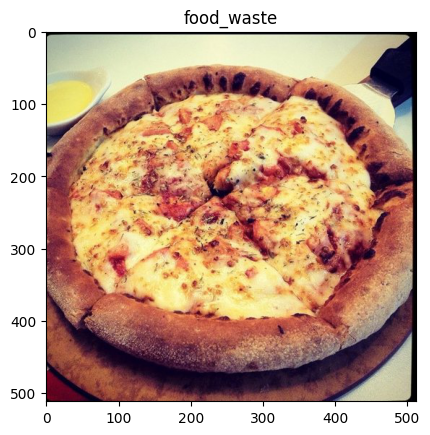

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
test_image=r'/content/Robotics_Dataset/train/food_waste/0_1.jpg'
image_result=Image.open(test_image)

from tensorflow.keras.preprocessing import image
test_image=image.load_img(test_image,target_size=(256,256))
test_image=image.img_to_array(test_image)
test_image=test_image/255
test_image=np.expand_dims(test_image,axis=0)
result=model.predict(test_image)
print(np.argmax(result))
Categories=['food_waste','metal_waste']
image_result=plt.imshow(image_result)
plt.title(Categories[np.argmax(result)])
plt.show()